# Breast Cancer Survival Prediction Support Vector Machine (SVM)

**Dataset:** Breast Cancer survival dataset — 4,024 patients  
**Target:** `status` — *Alive (0)* or *Dead (1)*  
**Model:** Support Vector Machine with RBF Kernel

```

In [ ]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                      StratifiedKFold, cross_val_score,
                                      cross_val_predict)
from sklearn.svm import SVC
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, accuracy_score, roc_curve,
    precision_score, recall_score, f1_score,
    log_loss, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import pointbiserialr
from collections import Counter

In [2]:
#Load Dataset & Basic Cleaning
df = pd.read_csv('../Dataset/Breast_Cancer.csv')
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (4024, 16)
Columns: ['age', 'race', 'marital_status', 't_stage', 'n_stage', '6th_stage', 'differentiate', 'grade', 'a_stage', 'tumor_size', 'estrogen_status', 'progesterone_status', 'regional_node_examined', 'reginol_node_positive', 'survival_months', 'status']


,age,race,marital_status,t_stage,n_stage,6th_stage,differentiate,grade,a_stage,tumor_size,estrogen_status,progesterone_status,regional_node_examined,reginol_node_positive,survival_months,status
0,68,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,4,Positive,Positive,24,1,60,Alive
1,50,White,Married,T2,N2,IIIA,Moderately differentiated,2,Regional,35,Positive,Positive,14,5,62,Alive
2,58,White,Divorced,T3,N3,IIIC,Moderately differentiated,2,Regional,63,Positive,Positive,14,7,75,Alive
3,58,White,Married,T1,N1,IIA,Poorly differentiated,3,Regional,18,Positive,Positive,2,1,84,Alive
4,47,White,Married,T2,N1,IIB,Poorly differentiated,3,Regional,41,Positive,Positive,3,1,50,Alive


### EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   age                     4024 non-null   int64 
 1   race                    4024 non-null   object
 2   marital_status          4024 non-null   object
 3   t_stage                 4024 non-null   object
 4   n_stage                 4024 non-null   object
 5   6th_stage               4024 non-null   object
 6   differentiate           4024 non-null   object
 7   grade                   4024 non-null   object
 8   a_stage                 4024 non-null   object
 9   tumor_size              4024 non-null   int64 
 10  estrogen_status         4024 non-null   object
 11  progesterone_status     4024 non-null   object
 12  regional_node_examined  4024 non-null   int64 
 13  reginol_node_positive   4024 non-null   int64 
 14  survival_months         4024 non-null   int64 
 15  stat

In [4]:
df.describe()

,age,tumor_size,regional_node_examined,reginol_node_positive,survival_months
count,4024.000000,4024.000000,4024.000000,4024.000000,4024.000000
mean,53.972167,30.473658,14.357107,4.158052,71.297962
std,8.963134,21.119696,8.099675,5.109331,22.921430
min,30.000000,1.000000,1.000000,1.000000,1.000000
25%,47.000000,16.000000,9.000000,1.000000,56.000000
50%,54.000000,25.000000,14.000000,2.000000,73.000000
75%,61.000000,38.000000,19.000000,5.000000,90.000000
max,69.000000,140.000000,61.000000,46.000000,107.000000


In [5]:
#no missing values

status
Alive    3408
Dead      616
Name: count, dtype: int64

Class proportions:
status
Alive    0.846918
Dead     0.153082
Name: proportion, dtype: float64


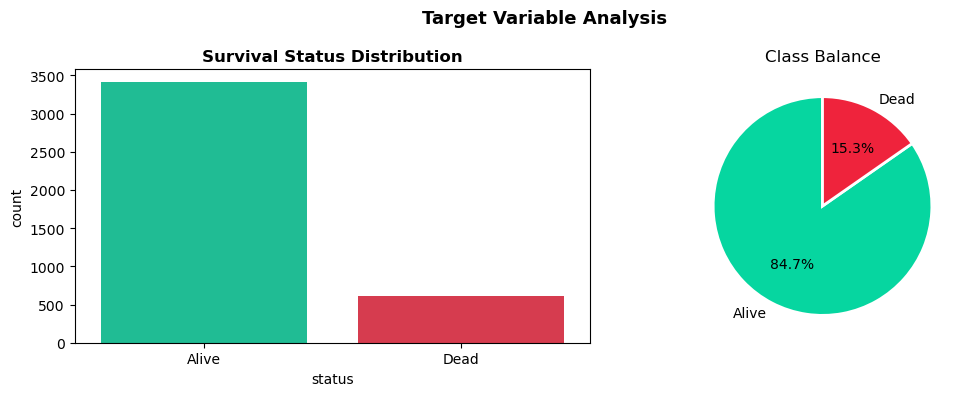

In [6]:
print(df['status'].value_counts())
print('\nClass proportions:')
print(df['status'].value_counts(normalize=True))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=df['status'], palette=['#06d6a0', '#ef233c'], ax=axes[0])
axes[0].set_title('Survival Status Distribution', fontweight='bold')
counts = df['status'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#06d6a0', '#ef233c'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')
plt.suptitle('Target Variable Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

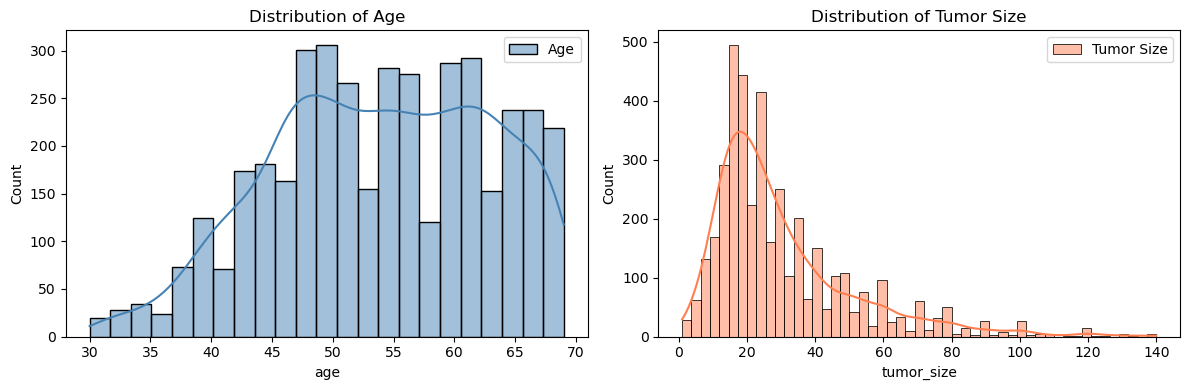

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['age'],        color='steelblue', kde=True, ax=axes[0], label='Age')
sns.histplot(df['tumor_size'], color='coral',     kde=True, ax=axes[1], label='Tumor Size')
axes[0].set_title('Distribution of Age');        axes[0].legend()
axes[1].set_title('Distribution of Tumor Size'); axes[1].legend()
plt.tight_layout(); plt.show()

### Drop Data-Leaking Feature

> `survival_months` records how long a patient survived after diagnosis — known only **after** the outcome. Including it hands the model the answer.

In [8]:
temp_status = (df['status'] == 'Dead').astype(int)
corr, p = pointbiserialr(temp_status, df['survival_months'])
print(f'Point-biserial r (Status vs survival_months): {corr:.3f},  p = {p:.2e}')
print('Strong correlation confirms post-outcome leakage — dropping.')
df = df.drop('survival_months', axis=1)
print(f'Remaining features: {df.shape[1] - 1} + target')

Point-biserial r (Status vs survival_months): -0.477,  p = 2.99e-227
Strong correlation confirms post-outcome leakage — dropping.
Remaining features: 14 + target


### Train / Test Split

> Split happens **first** — before feature engineering, encoding, or scaling.

In [9]:
X_raw = df.drop('status', axis=1)
y     = (df['status'] == 'Dead').astype(int)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print('\nTrain class proportions:', y_train.value_counts(normalize=True).to_dict())
print('Test  class proportions:', y_test.value_counts(normalize=True).to_dict())

Train: (3219, 14)  |  Test: (805, 14)

Train class proportions: {0: 0.8468468468468469, 1: 0.15315315315315314}
Test  class proportions: {0: 0.8472049689440994, 1: 0.15279503105590062}


### Feature Engineering

| Feature | Source columns removed | Rationale |
|---|---|---|
| `stage_severity` | `t_stage`, `n_stage` | Combined T+N ordinal severity score |
| `lymph_node_burden` | kept raw cols too | Proportion of positive nodes |
| `grade_num` | `grade` | Ordinal 1-4 tumour grade |
| `hormone_positive_count` | `estrogen_status`, `progesterone_status` | Count of positive receptors (0-2) |
| `tumor_burden` | — | Tumor size x stage severity |
| `is_distant` | `a_stage` | Binary distant metastasis flag |
| `high_grade` | `differentiate` | Binary most-aggressive flag |

In [10]:
def engineer_features(df_in):
    """Engineer clinical features. Drops source columns to prevent multicollinearity."""
    df_out = df_in.copy()

    t_map     = {'T1': 1, 'T2': 2, 'T3': 3, 'T4': 4}
    n_map     = {'N1': 1, 'N2': 2, 'N3': 3}
    grade_map = {'1': 1, '2': 2, '3': 3, ' anaplastic; Grade IV': 4}

    df_out['stage_severity']         = df_out['t_stage'].map(t_map) + df_out['n_stage'].map(n_map)
    df_out['lymph_node_burden']      = df_out['reginol_node_positive'] / (df_out['regional_node_examined'] + 1)
    df_out['grade_num']              = df_out['grade'].map(grade_map)
    df_out['hormone_positive_count'] = (
        (df_out['estrogen_status'] == 'Positive').astype(int) +
        (df_out['progesterone_status'] == 'Positive').astype(int)
    )
    df_out['tumor_burden'] = df_out['tumor_size'] * df_out['stage_severity']
    df_out['is_distant']   = (df_out['a_stage'] == 'Distant').astype(int)
    df_out['high_grade']   = df_out['differentiate'].isin(['Poorly differentiated','Undifferentiated']).astype(int)

    # Drop source cols to avoid multicollinearity
    source_cols = ['t_stage','n_stage','grade','a_stage','differentiate',
                   'estrogen_status','progesterone_status']
    df_out = df_out.drop(columns=source_cols)
    return df_out


X_train_eng = engineer_features(X_train_raw)
X_test_eng  = engineer_features(X_test_raw)

print(f'Shape after engineering: {X_train_eng.shape}')
print('Columns:', X_train_eng.columns.tolist())
X_train_eng.head()

Shape after engineering: (3219, 14)
Columns: ['age', 'race', 'marital_status', '6th_stage', 'tumor_size', 'regional_node_examined', 'reginol_node_positive', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'tumor_burden', 'is_distant', 'high_grade']


,age,race,marital_status,6th_stage,tumor_size,regional_node_examined,reginol_node_positive,stage_severity,lymph_node_burden,grade_num,hormone_positive_count,tumor_burden,is_distant,high_grade
1909,50,White,Married,IIB,40,13,1,3,0.071429,1,2,120,0,0
1635,59,White,Married,IIA,12,11,2,2,0.166667,3,2,24,0,1
239,44,White,Married,IIA,11,8,2,2,0.222222,2,2,22,0,0
898,59,White,Divorced,IIIA,25,32,5,4,0.151515,2,1,100,0,0
2679,69,White,Married,IIA,18,4,1,2,0.200000,1,2,36,0,0


In [12]:
# Correlation check on training data only
new_features = ['stage_severity','lymph_node_burden','grade_num',
                'hormone_positive_count','tumor_burden','is_distant','high_grade']
rows = []
for feat in new_features:
    r, p = pointbiserialr(y_train.values, X_train_eng[feat].values)
    rows.append({'Feature': feat, 'r': round(r,3), 'p_value': f'{p:.2e}',
                 'Significant': 'Yes' if p < 0.05 else 'No'})
print('Point-biserial correlation with target (train only):')
print(pd.DataFrame(rows).sort_values('r', key=abs, ascending=False).to_string(index=False))

Point-biserial correlation with target (train only):
               Feature      r  p_value Significant
     lymph_node_burden  0.277 1.04e-57         Yes
        stage_severity  0.259 1.35e-50         Yes
hormone_positive_count -0.217 9.40e-36         Yes
          tumor_burden  0.187 1.33e-26         Yes
             grade_num  0.175 1.93e-23         Yes
            high_grade  0.171 1.85e-22         Yes
            is_distant  0.104 2.99e-09         Yes


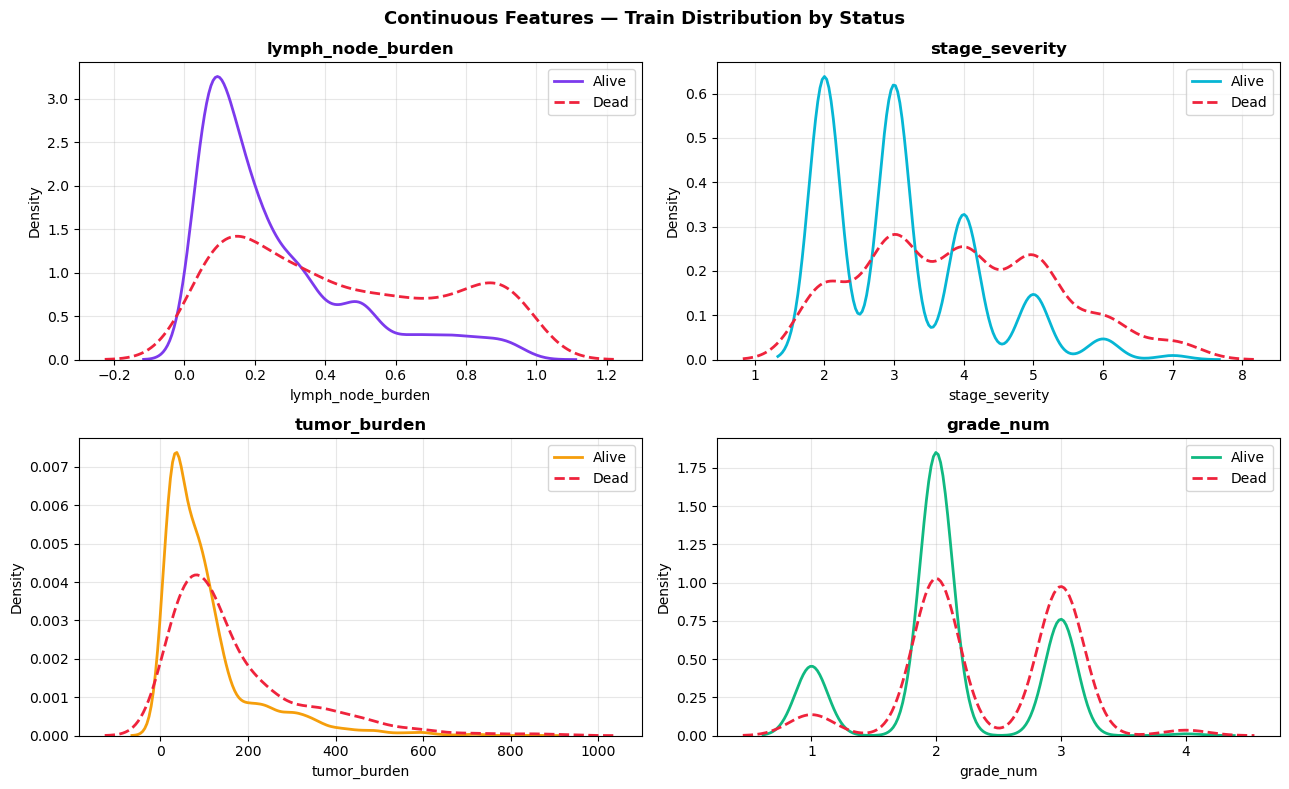

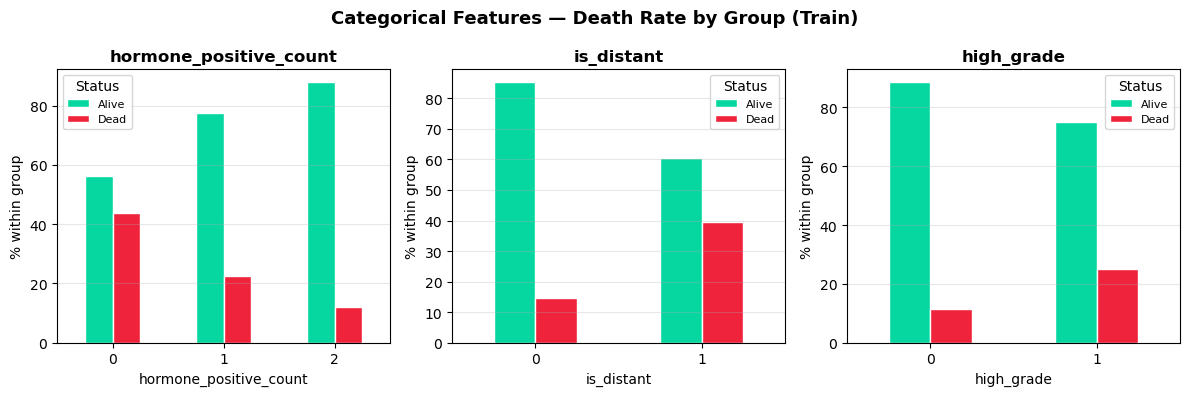

In [13]:
train_plot = X_train_eng.copy()
train_plot['status'] = y_train.map({0:'Alive',1:'Dead'}).values

# KDE plots for continuous engineered features
cont_feats = ['lymph_node_burden','stage_severity','tumor_burden','grade_num']
colors     = ['#7c3aed','#06b6d4','#f59e0b','#10b981']
fig, axes  = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat, color in zip(axes.flatten(), cont_feats, colors):
    for status, ls in zip(['Alive','Dead'],['-','--']):
        c = color if status == 'Alive' else '#ef233c'
        sns.kdeplot(train_plot[train_plot['status']==status][feat],
                    ax=ax, label=status, linestyle=ls, color=c, linewidth=2)
    ax.set_title(feat, fontweight='bold'); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Continuous Features — Train Distribution by Status', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Bar charts for binary/count features
cat_eng = ['hormone_positive_count','is_distant','high_grade']
fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, feat in zip(axes, cat_eng):
    ct = pd.crosstab(train_plot[feat], train_plot['status'], normalize='index') * 100
    ct.plot(kind='bar', ax=ax, color=['#06d6a0','#ef233c'], edgecolor='white', rot=0)
    ax.set_title(feat, fontweight='bold'); ax.set_ylabel('% within group')
    ax.legend(title='Status', fontsize=8); ax.grid(axis='y', alpha=0.3)
plt.suptitle('Categorical Features — Death Rate by Group (Train)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Outlier Detection & Capping

> SVM is sensitive to outliers. IQR method identifies outliers; values are **Winsorized** (capped at bounds) rather than removed to preserve sample size.  
> Bounds are computed on training data and applied to both train and test.

Feature                               Outliers   % of train
------------------------------------------------------------
age                                          0         0.0%
tumor_size                                 177         5.5%
regional_node_examined                      53         1.6%
reginol_node_positive                      270         8.4%
tumor_burden                               299         9.3%


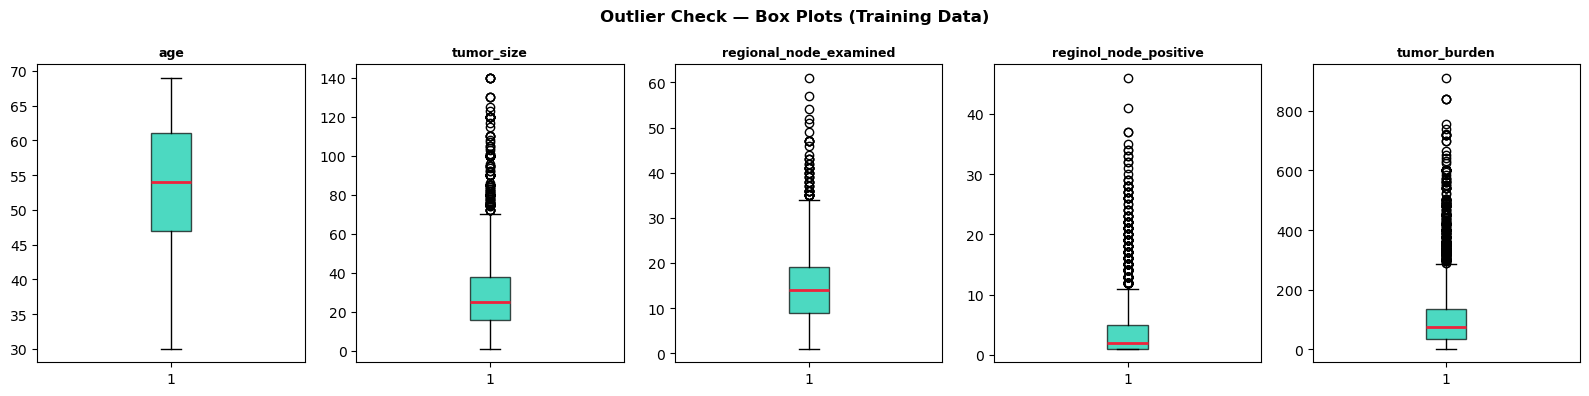

In [14]:
num_cols_check = ['age','tumor_size','regional_node_examined','reginol_node_positive','tumor_burden']

print(f'{"Feature":<35} {"Outliers":>10} {"% of train":>12}')
print('-' * 60)
for col in num_cols_check:
    Q1, Q3 = X_train_eng[col].quantile(0.25), X_train_eng[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((X_train_eng[col] < Q1-1.5*IQR) | (X_train_eng[col] > Q3+1.5*IQR)).sum()
    print(f'{col:<35} {n_out:>10} {n_out/len(X_train_eng)*100:>11.1f}%')

fig, axes = plt.subplots(1, len(num_cols_check), figsize=(16, 4))
for ax, col in zip(axes, num_cols_check):
    ax.boxplot(X_train_eng[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor='#00c9a7', alpha=0.7),
               medianprops=dict(color='#ef233c', linewidth=2))
    ax.set_title(col, fontsize=9, fontweight='bold')
plt.suptitle('Outlier Check — Box Plots (Training Data)', fontweight='bold')
plt.tight_layout(); plt.show()

In [15]:
# Winsorize using bounds derived from training data
X_train_capped = X_train_eng.copy()
X_test_capped  = X_test_eng.copy()
cap_bounds     = {}

for col in num_cols_check:
    Q1, Q3    = X_train_eng[col].quantile(0.25), X_train_eng[col].quantile(0.75)
    IQR       = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    cap_bounds[col] = (lower, upper)
    X_train_capped[col] = X_train_eng[col].clip(lower, upper)
    X_test_capped[col]  = X_test_eng[col].clip(lower, upper)   # train bounds applied to test

print('Winsorization applied using training bounds')

Winsorization applied using training bounds


### Encoding

In [16]:
cat_cols_remaining = ['race', 'marital_status', '6th_stage']

# One-hot encoding — correct for nominal categoricals with a distance-based model (SVM).
# fit on train only, then apply same columns to test (align handles unseen categories safely).
X_train_enc = pd.get_dummies(X_train_capped, columns=cat_cols_remaining)
X_test_enc  = pd.get_dummies(X_test_capped,  columns=cat_cols_remaining)

# Align test to train columns (fills any missing dummies with 0)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

print(f'Shape after OHE — Train: {X_train_enc.shape} | Test: {X_test_enc.shape}')
print('Columns:', X_train_enc.columns.tolist())

Shape after OHE — Train: (3219, 24) | Test: (805, 24)
Columns: ['age', 'tumor_size', 'regional_node_examined', 'reginol_node_positive', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'tumor_burden', 'is_distant', 'high_grade', 'race_Black', 'race_Other', 'race_White', 'marital_status_Divorced', 'marital_status_Married', 'marital_status_Separated', 'marital_status_Single ', 'marital_status_Widowed', '6th_stage_IIA', '6th_stage_IIB', '6th_stage_IIIA', '6th_stage_IIIB', '6th_stage_IIIC']


###Feature Scaling Fit on Original Train

> StandardScaler fitted on **original `X_train`** (before SMOTE). SVM is distance-based, scaling is mandatory.

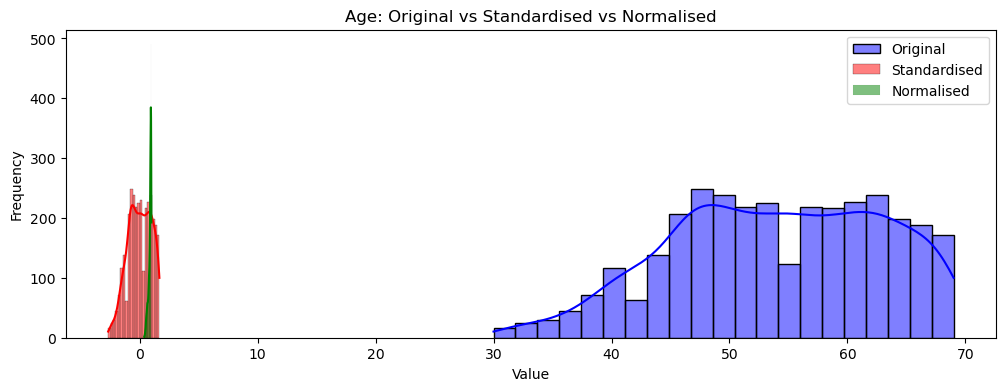

Scaling done.  Train: (3219, 24)  |  Test: (805, 24)


In [17]:
# Illustrate: original vs standardised vs normalised
s_x = X_train_enc[['age','tumor_size','stage_severity','lymph_node_burden']]
std_vals  = preprocessing.StandardScaler().fit_transform(s_x)
norm_vals = preprocessing.Normalizer().fit_transform(s_x)

plt.figure(figsize=(12,4))
sns.histplot(s_x['age'],     color='blue',  label='Original',     kde=True, alpha=0.5)
sns.histplot(std_vals[:,0],  color='red',   label='Standardised', kde=True, alpha=0.5)
sns.histplot(norm_vals[:,0], color='green', label='Normalised',   kde=True, alpha=0.5)
plt.title('Age: Original vs Standardised vs Normalised')
plt.xlabel('Value'); plt.ylabel('Frequency'); plt.legend()
plt.show()

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_enc)
X_test_sc  = scaler.transform(X_test_enc)
X_train_sc_df = pd.DataFrame(X_train_sc, columns=X_train_enc.columns)
X_test_sc_df  = pd.DataFrame(X_test_sc,  columns=X_test_enc.columns)

print(f'Scaling done.  Train: {X_train_sc.shape}  |  Test: {X_test_sc.shape}')

### Wrapper RFE on Training Data Only

In [18]:
print('Before SMOTE (for RFE):', Counter(y_train))
X_train_sm_rfe, y_train_sm_rfe = SMOTE(random_state=42).fit_resample(X_train_sc, y_train)
print('After  SMOTE (for RFE):', Counter(y_train_sm_rfe))

Before SMOTE (for RFE): Counter({0: 2726, 1: 493})
After  SMOTE (for RFE): Counter({0: 2726, 1: 2726})


In [19]:
rfe = RFE(SVC(kernel='linear', C=1.0, class_weight='balanced'), n_features_to_select=10)
rfe.fit(X_train_sm_rfe, y_train_sm_rfe)

selected_features = list(X_train_enc.columns[rfe.support_])
rfe_df = pd.DataFrame({'Feature': X_train_enc.columns,
                        'Selected': rfe.support_,
                        'Rank': rfe.ranking_}).sort_values('Rank')
print(rfe_df.to_string(index=False))
print(f'\nSelected {len(selected_features)} features: {selected_features}')

                 Feature  Selected  Rank
                     age      True     1
  marital_status_Married      True     1
              race_Other      True     1
            tumor_burden      True     1
  hormone_positive_count      True     1
               grade_num      True     1
              race_Black      True     1
          stage_severity      True     1
       lymph_node_burden      True     1
              tumor_size      True     1
  marital_status_Widowed     False     2
              high_grade     False     3
marital_status_Separated     False     4
  regional_node_examined     False     5
 marital_status_Divorced     False     6
              race_White     False     7
          6th_stage_IIIB     False     8
   reginol_node_positive     False     9
           6th_stage_IIA     False    10
              is_distant     False    11
          6th_stage_IIIC     False    12
           6th_stage_IIB     False    13
  marital_status_Single      False    14
          6th_st

## Apply RFE-Selected Features

> Final model trains **only on RFE-selected features**.

In [20]:
X_train_rfe = X_train_sc_df[selected_features].values
X_test_rfe  = X_test_sc_df[selected_features].values
print(f'Features used in model: {selected_features}')
print(f'Train: {X_train_rfe.shape}  |  Test: {X_test_rfe.shape}')

Features used in model: ['age', 'tumor_size', 'stage_severity', 'lymph_node_burden', 'grade_num', 'hormone_positive_count', 'tumor_burden', 'race_Black', 'race_Other', 'marital_status_Married']
Train: (3219, 10)  |  Test: (805, 10)


### Class Imbalance — SMOTE inside Pipeline

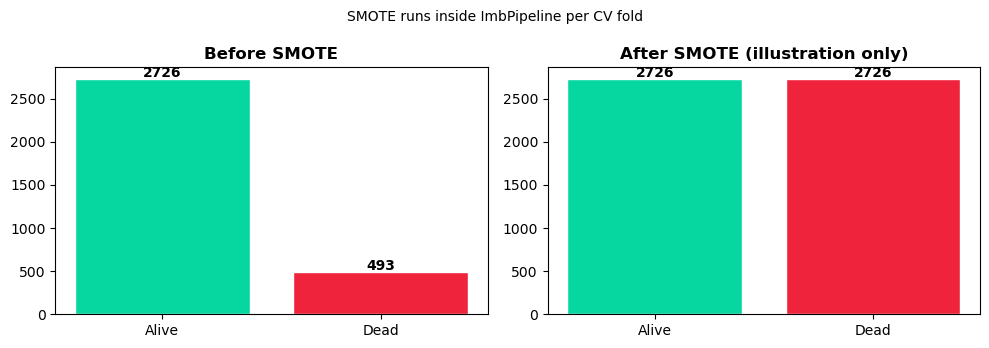

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
before = Counter(y_train)
bars  = axes[0].bar(['Alive','Dead'], [before[0],before[1]], color=['#06d6a0','#ef233c'], edgecolor='white')
axes[0].set_title('Before SMOTE', fontweight='bold')
for b, v in zip(bars,[before[0],before[1]]):
    axes[0].text(b.get_x()+b.get_width()/2, v+20, str(v), ha='center', fontweight='bold')

_, y_demo = SMOTE(random_state=42).fit_resample(X_train_rfe, y_train)
after = Counter(y_demo)
bars2 = axes[1].bar(['Alive','Dead'], [after[0],after[1]], color=['#06d6a0','#ef233c'], edgecolor='white')
axes[1].set_title('After SMOTE (illustration only)', fontweight='bold')
for b, v in zip(bars2,[after[0],after[1]]):
    axes[1].text(b.get_x()+b.get_width()/2, v+20, str(v), ha='center', fontweight='bold')

plt.suptitle('SMOTE runs inside ImbPipeline per CV fold', fontsize=10)
plt.tight_layout(); plt.show()

### Baseline Model

=== Baseline SVM (C=1.0) ===
Train accuracy: 75.09%
Test  accuracy: 70.19%
              precision    recall  f1-score   support

       Alive       0.90      0.73      0.81       682
        Dead       0.27      0.54      0.35       123

    accuracy                           0.70       805
   macro avg       0.58      0.63      0.58       805
weighted avg       0.80      0.70      0.74       805



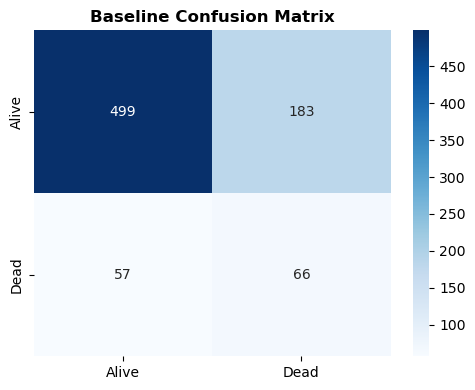

In [22]:
baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm',   SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,
                  class_weight='balanced', random_state=42))
])
baseline.fit(X_train_rfe, y_train)
y_pred_base = baseline.predict(X_test_rfe)

print('=== Baseline SVM (C=1.0) ===')
print(f'Train accuracy: {baseline.score(X_train_rfe, y_train)*100:.2f}%')
print(f'Test  accuracy: {accuracy_score(y_test, y_pred_base)*100:.2f}%')
print(classification_report(y_test, y_pred_base, target_names=['Alive','Dead']))

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_base), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Alive','Dead'], yticklabels=['Alive','Dead'])
plt.title('Baseline Confusion Matrix', fontweight='bold'); plt.tight_layout(); plt.show()

### Hyperparameter Tuning — GridSearchCV

In [ ]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svm',   SVC(probability=True, class_weight='balanced', random_state=42))
])

param_grid = {
    'svm__C'     : [0.1, 1.0, 10.0],
    'svm__gamma' : ['scale', 'auto'],
    'svm__kernel': ['rbf', 'linear']
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(pipeline, param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)
grid.fit(X_train_rfe, y_train)

print(f'\nBest parameters : {grid.best_params_}')
print(f'Best CV ROC-AUC : {grid.best_score_:.4f}')

best_model       = grid.best_estimator_
best_svm_params  = {k.replace('svm__',''):v for k,v in grid.best_params_.items()}

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Best CV ROC-AUC : 0.7478

Train accuracy: 71.73%
Test  accuracy: 68.32%


In [ ]:
# Final model — refit best pipeline from GridSearch on full training data
best_model.fit(X_train_rfe, y_train)
y_prob       = best_model.predict_proba(X_test_rfe)[:, 1]
y_pred_final = best_model.predict(X_test_rfe)

print(f'Threshold: 0.50 (default — SMOTE + class_weight handle imbalance)')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred_final):.4f}')
print()
print(classification_report(y_test, y_pred_final, target_names=['Alive','Dead']))

### Model Evaluation

In [ ]:
acc  = accuracy_score(y_test, y_pred_final)
auc  = roc_auc_score(y_test, y_prob)
prec = precision_score(y_test, y_pred_final, pos_label=1, zero_division=0)
rec  = recall_score(y_test, y_pred_final, pos_label=1)
f1   = f1_score(y_test, y_pred_final, pos_label=1)
ap   = average_precision_score(y_test, y_prob)

print('=' * 50)
print('        SVM MODEL PERFORMANCE SUMMARY')
print('=' * 50)
print(f'  Accuracy              : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  ROC-AUC               : {auc:.4f}')
print(f'  Average Precision     : {ap:.4f}')
print(f'  Precision (Dead)      : {prec:.4f}')
print(f'  Recall    (Dead)      : {rec:.4f}')
print(f'  F1-Score  (Dead)      : {f1:.4f}')
print('=' * 50)

        SVM MODEL PERFORMANCE SUMMARY
  Accuracy              : 0.7441  (74.41%)
  ROC-AUC               : 0.7043
  Average Precision     : 0.3066
  Log Loss              : 0.6053
  Precision (Dead)      : 0.2995
  Recall    (Dead)      : 0.5041
  F1-Score  (Dead)      : 0.3758


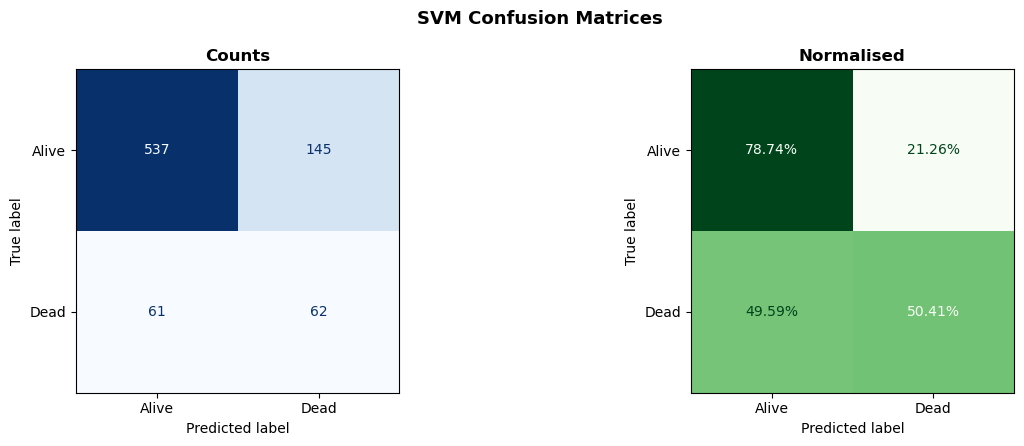

In [27]:
cm = confusion_matrix(y_test, y_pred_final)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ConfusionMatrixDisplay(cm, display_labels=['Alive','Dead']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Counts', fontweight='bold')
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm, display_labels=['Alive','Dead']).plot(ax=axes[1], colorbar=False, cmap='Greens', values_format='.2%')
axes[1].set_title('Normalised', fontweight='bold')
plt.suptitle('SVM Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

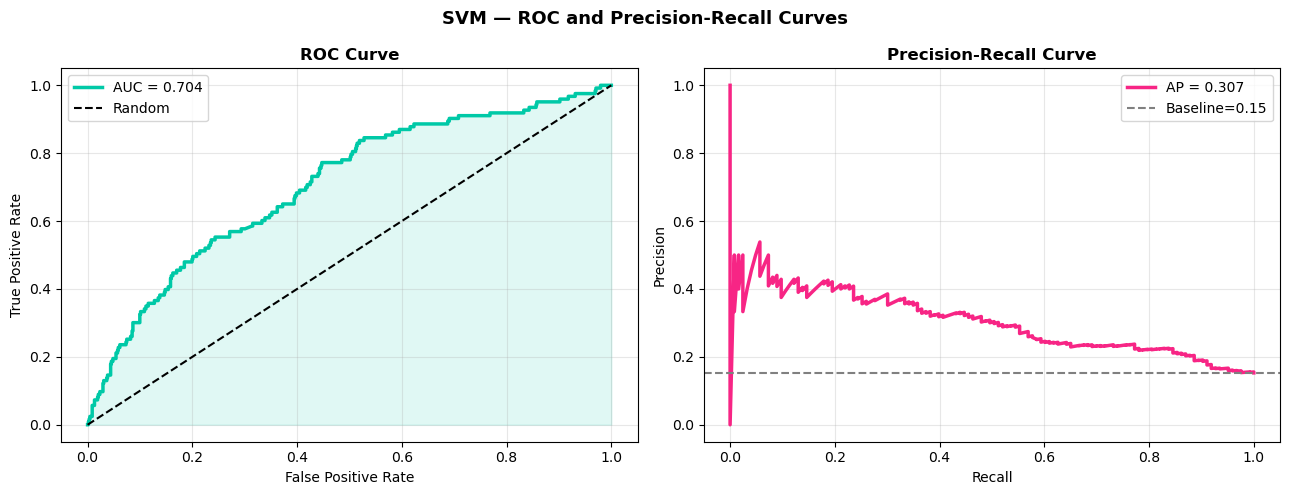

In [28]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, color='#00c9a7', lw=2.5, label=f'AUC = {auc:.3f}')
axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Random')
axes[0].fill_between(fpr, tpr, alpha=0.12, color='#00c9a7')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

prec_vals, rec_vals, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec_vals, prec_vals, color='#f72585', lw=2.5, label=f'AP = {ap:.3f}')
axes[1].axhline(y_test.mean(), color='gray', ls='--', lw=1.5, label=f'Baseline={y_test.mean():.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('SVM — ROC and Precision-Recall Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

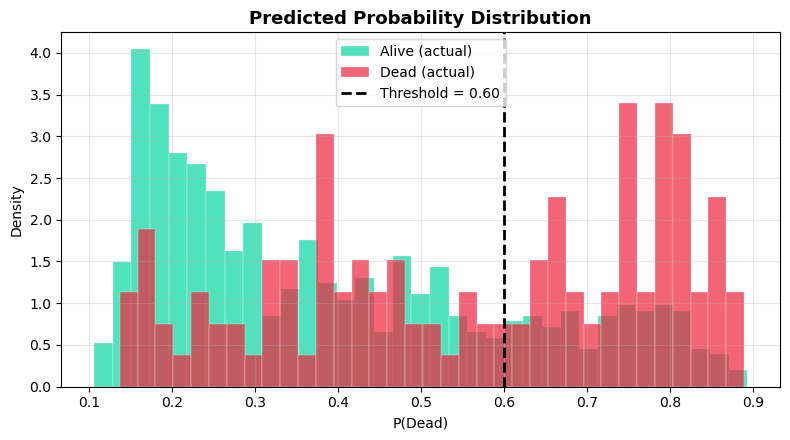

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.hist(y_prob[y_test==0], bins=35, alpha=0.70, color='#06d6a0', label='Alive (actual)', density=True, edgecolor='white', lw=0.3)
plt.hist(y_prob[y_test==1], bins=35, alpha=0.70, color='#ef233c', label='Dead (actual)',  density=True, edgecolor='white', lw=0.3)
plt.axvline(0.50, color='black', ls='--', lw=2, label='Threshold = 0.50')
plt.xlabel('P(Dead)'); plt.ylabel('Density')
plt.title('Predicted Probability Distribution', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

### Feature Importance — Permutation Importance

>  SMOTE must never touch test data.

In [30]:
# Fit standalone SVM with best params on SMOTE-balanced train
X_sm_final, y_sm_final = SMOTE(random_state=42).fit_resample(X_train_rfe, y_train)
svm_for_perm = SVC(**best_svm_params, probability=True, class_weight='balanced', random_state=42)
svm_for_perm.fit(X_sm_final, y_sm_final)

print(f'Standalone SVM test accuracy: {accuracy_score(y_test, svm_for_perm.predict(X_test_rfe))*100:.2f}%')

Standalone SVM test accuracy: 68.32%


In [31]:
perm = permutation_importance(
    svm_for_perm, X_test_rfe, y_test,
    n_repeats=15, random_state=42, scoring='roc_auc'
)

perm_df = pd.DataFrame({
    'Feature'    : selected_features,
    'Importance' : perm.importances_mean,
    'Std'        : perm.importances_std
}).sort_values('Importance', ascending=False)

print('Permutation Importances (ROC-AUC drop when feature shuffled):')
print(perm_df.to_string(index=False))

Permutation Importances (ROC-AUC drop when feature shuffled):
               Feature  Importance      Std
     lymph_node_burden    0.053395 0.008408
        stage_severity    0.027856 0.010049
hormone_positive_count    0.016041 0.007088
                   age    0.012966 0.007695
             grade_num    0.009752 0.009744
            race_Black    0.006064 0.007005
            race_Other    0.005533 0.005807
            tumor_size    0.003092 0.003522
          tumor_burden    0.001971 0.003842
marital_status_Married   -0.003164 0.008495


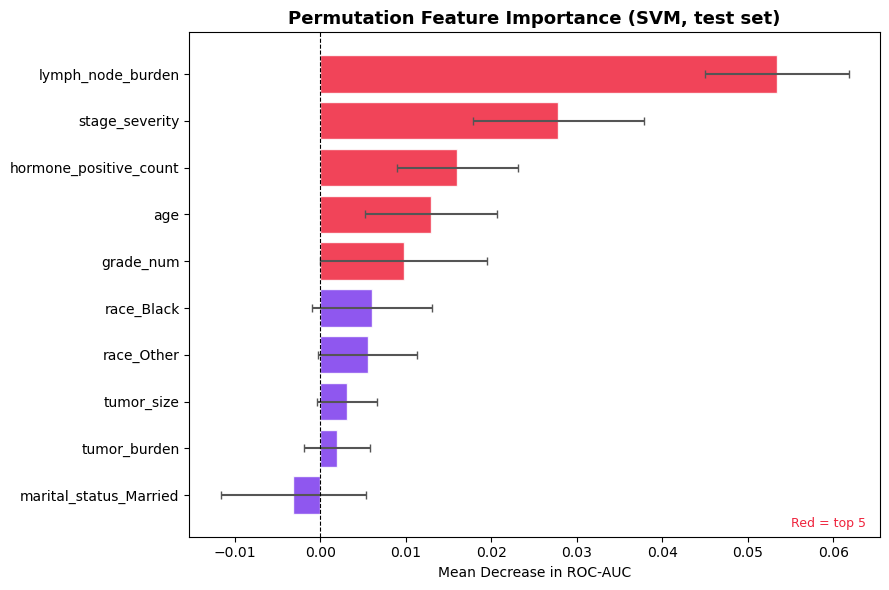

In [32]:
sorted_df = perm_df.sort_values('Importance', ascending=True)
colors_pi = ['#ef233c' if i >= len(sorted_df)-5 else '#7c3aed' for i in range(len(sorted_df))]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(sorted_df['Feature'], sorted_df['Importance'],
        xerr=sorted_df['Std'], color=colors_pi, alpha=0.85,
        error_kw={'elinewidth':1.5,'ecolor':'#555','capsize':3}, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Mean Decrease in ROC-AUC')
ax.set_title('Permutation Feature Importance (SVM, test set)', fontsize=13, fontweight='bold')
ax.annotate('Red = top 5', xy=(0.98,0.02), xycoords='axes fraction', ha='right', fontsize=9, color='#ef233c')
plt.tight_layout(); plt.show()

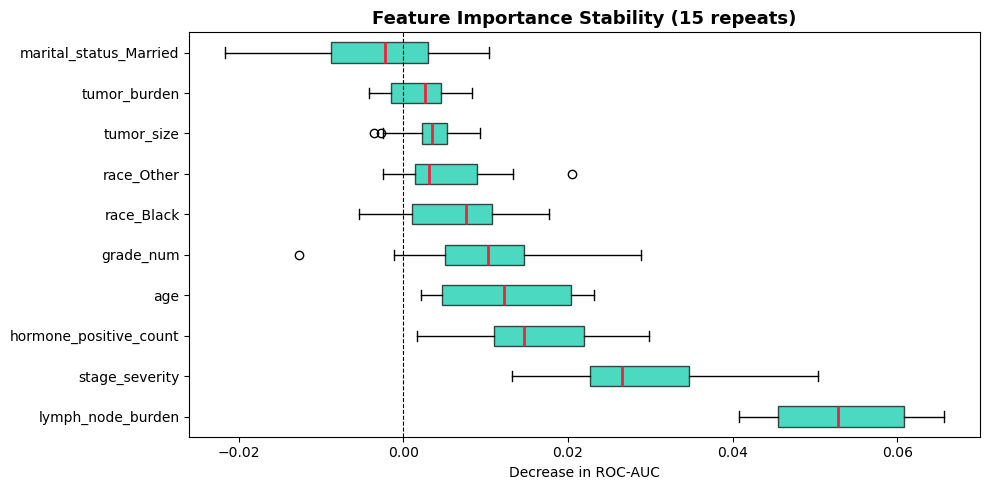

In [ ]:
top_n       = min(10, len(perm_df))
top10_names = perm_df.head(top_n)['Feature'].tolist()
top10_idx   = [selected_features.index(f) for f in top10_names]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(perm.importances[top10_idx].T, vert=False, labels=top10_names,
           patch_artist=True,
           boxprops=dict(facecolor='#00c9a7', alpha=0.7),
           medianprops=dict(color='#ef233c', linewidth=2))
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Decrease in ROC-AUC')
ax.set_title('Feature Importance Stability (15 repeats)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### Cross-Validation Tuned Pipeline

> CV uses the **tuned pipeline** with best params from GridSearch, not the default-param pipeline.

5-Fold CV ROC-AUC (tuned params, SMOTE per fold):
  Fold 1: 0.7148
  Fold 2: 0.7622
  Fold 3: 0.7187
  Fold 4: 0.7715
  Fold 5: 0.7720

  Mean : 0.7478
  Std  : 0.0257


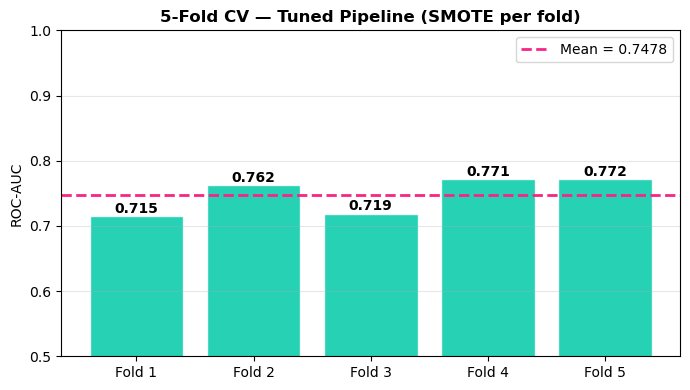

In [34]:
cv_scores = cross_val_score(
    tuned_pipeline, X_train_rfe, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc', n_jobs=-1
)

print('5-Fold CV ROC-AUC (tuned params, SMOTE per fold):')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

plt.figure(figsize=(7, 4))
bars = plt.bar([f'Fold {i}' for i in range(1,6)], cv_scores,
               color='#00c9a7', edgecolor='white', alpha=0.85)
plt.axhline(cv_scores.mean(), color='#f72585', ls='--', lw=2,
            label=f'Mean = {cv_scores.mean():.4f}')
plt.ylim(0.5, 1.0); plt.ylabel('ROC-AUC')
plt.title('5-Fold CV — Tuned Pipeline (SMOTE per fold)', fontsize=12, fontweight='bold')
plt.legend(); plt.grid(axis='y', alpha=0.3)
for bar, score in zip(bars, cv_scores):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{score:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout(); plt.show()

### GridSearch Results Heatmap

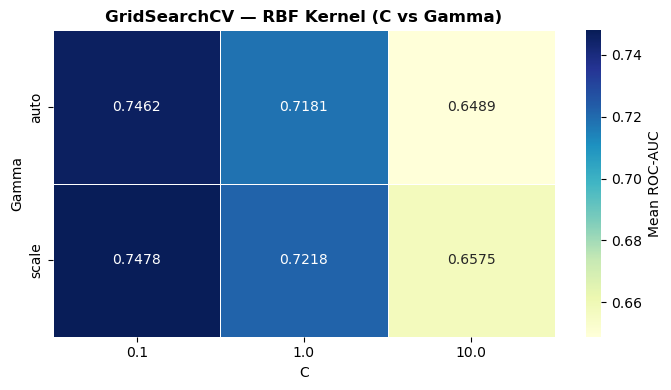

In [35]:
results_df = pd.DataFrame(grid.cv_results_)
rbf_res    = results_df[results_df['param_svm__kernel']=='rbf'][['param_svm__C','param_svm__gamma','mean_test_score']]
rbf_pivot  = rbf_res.pivot(index='param_svm__gamma', columns='param_svm__C', values='mean_test_score')

plt.figure(figsize=(7, 4))
sns.heatmap(rbf_pivot, annot=True, fmt='.4f', cmap='YlGnBu',
            linewidths=0.5, cbar_kws={'label':'Mean ROC-AUC'})
plt.title('GridSearchCV — RBF Kernel (C vs Gamma)', fontweight='bold')
plt.xlabel('C'); plt.ylabel('Gamma')
plt.tight_layout(); plt.show()